In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

print("Setup complete. Libraries are ready.")

Setup complete. Libraries are ready.


In [117]:
#load
df = pd.read_csv('/content/sample_data/student_lifestyle_100k.csv')

In [118]:
#سوينا عرض للبيانات
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [119]:
# عدد الصفوف والاعمدة
print("shape: ", df.shape, "\n")
# معلومات عامة
df.info()

shape:  (100000, 11) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [120]:
#معلومات احصائية
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Student_ID,100000.0,51000.500000,28867.657797,1001.00,26000.75,51000.5,76000.25,101000.0
Age,100000.0,21.009010,2.000382,18.00,19.00,21.0,23.00,24.0
CGPA,100000.0,2.898316,0.532240,1.56,2.45,2.9,3.35,4.0
Sleep_Duration,100000.0,6.996425,1.498682,3.00,6.00,7.0,8.00,12.0
Study_Hours,100000.0,4.509517,1.976076,0.00,3.20,4.5,5.80,12.8
Social_Media_Hours,100000.0,3.503288,1.486852,0.00,2.50,3.5,4.50,10.0
Physical_Activity,100000.0,74.353180,43.366963,0.00,37.00,74.0,112.00,149.0
Stress_Level,100000.0,4.131660,1.424151,2.00,3.00,4.0,5.00,10.0


In [121]:
# نعرض اسماء الاعمدة عشان اذا نبي نضيف اعمدة او ننظف البيانات
print(df.columns.tolist())

#print(df.dtypes)

#  ممكن اغير Sleep_Duration و Social_Media_Hours و Study_Hours الى int

['Student_ID', 'Age', 'Gender', 'Department', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Depression']


In [122]:
# نشوف انواع البيانات في الاعمدة
print(df.dtypes)

Student_ID              int64
Age                     int64
Gender                 object
Department             object
CGPA                  float64
Sleep_Duration        float64
Study_Hours           float64
Social_Media_Hours    float64
Physical_Activity       int64
Stress_Level            int64
Depression               bool
dtype: object


In [123]:
print(df["Department"].unique())

['Science' 'Engineering' 'Medical' 'Arts' 'Business']


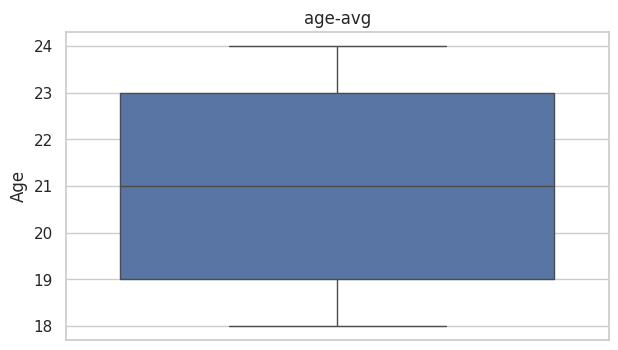

In [124]:
#هنا حسبنا متوسط الاعمار
sns.boxplot(data=df['Age'])
plt.title("age-avg")
plt.show()

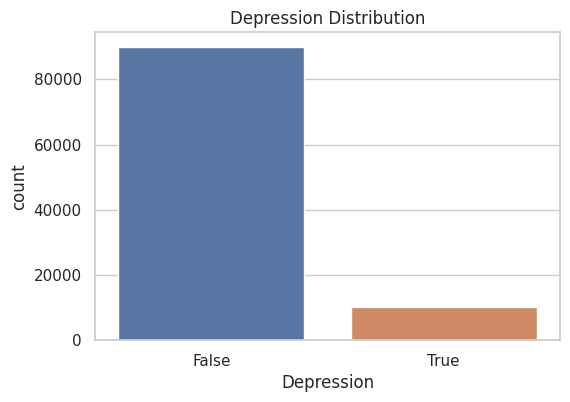

In [125]:
#هنا حسبنا المصابين والغير مصابين بالاكتئاب
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Depression', hue='Depression', legend=False)
plt.title("Depression Distribution")
plt.show()

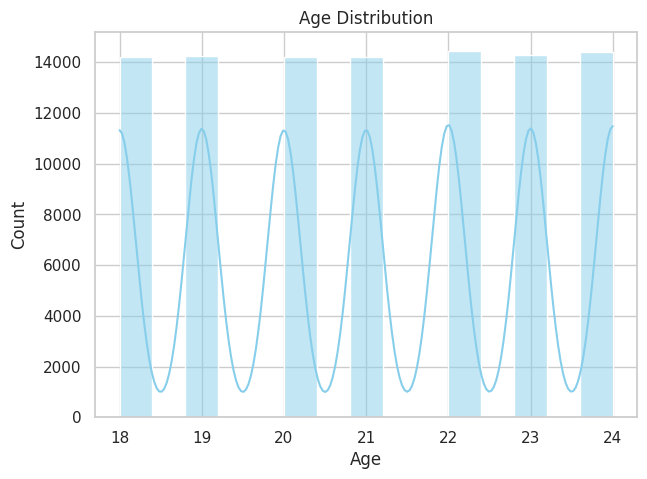

In [126]:
#هنا حسبناالاعمار
plt.figure(figsize=(7,5))
sns.histplot(df['Age'], bins=15, kde=True, color='skyblue')

plt.title("Age Distribution")
plt.show()

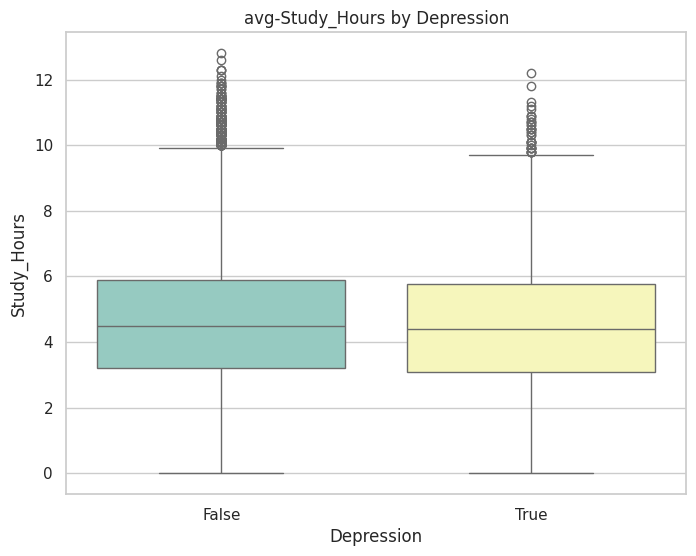

In [127]:
#اثر الاكتئاب ومعدل ساعات الدراسة
#لا يوجد تاثير للاكتئاب على معدل ساعات الدراسة
#ملاحظةاستخدمت hue='Depression', legend=False لا يوجد لها علاقة بالرسمة بس عشان اخفي نص مزعج

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Depression', y='Study_Hours', palette='Set3', hue='Depression', legend=False)
plt.title("avg-Study_Hours by Depression")
plt.show()

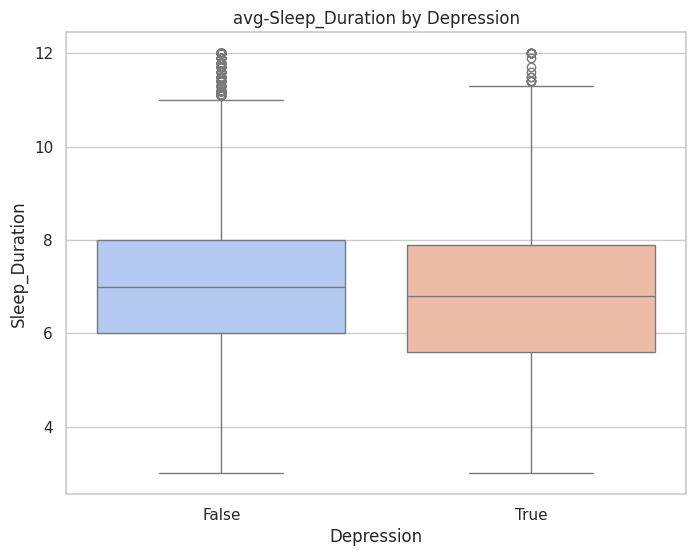

In [128]:
#العلاقة هنا ان المرضى بالاكتئاب ينامون ساعات اقل من غير المصابين
#ملاحظةاستخدمت hue='Depression', legend=False لا يوجد لها علاقة بالرسمة بس عشان اخفي نص مزعج
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Depression', y='Sleep_Duration', palette="coolwarm", hue='Depression', legend=False)
plt.title("avg-Sleep_Duration by Depression")
plt.show()

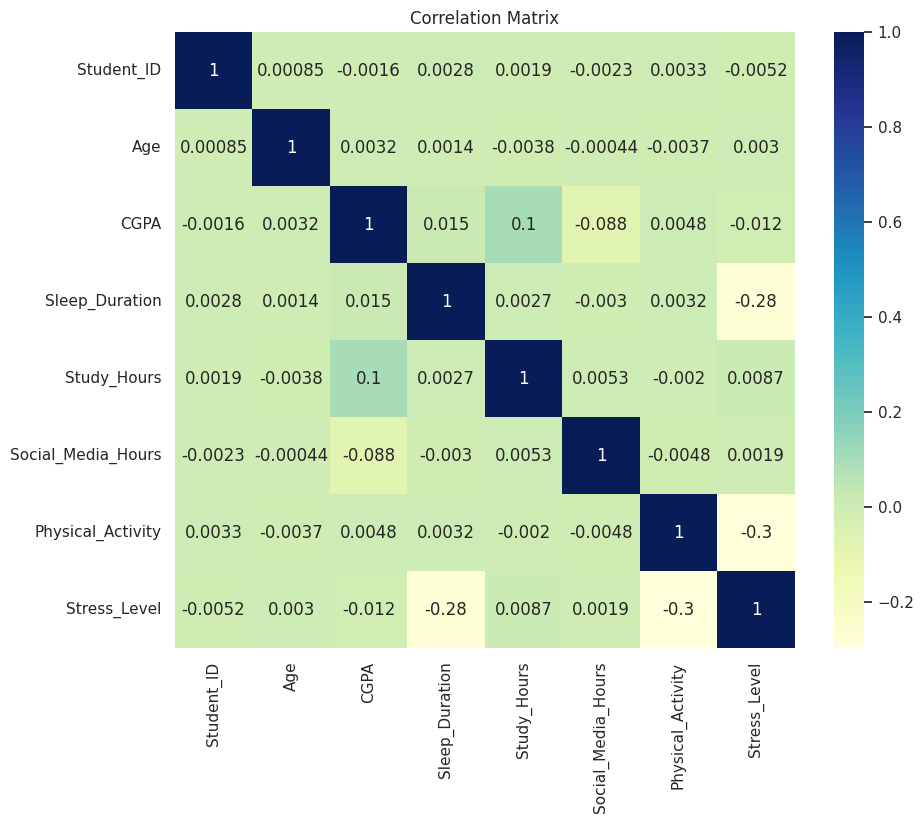

In [129]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation Matrix")
plt.show()

In [130]:
#لا توجد قيم مفقودة لذلك ماراح نستخدم mean  او median
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Department,0
CGPA,0
Sleep_Duration,0
Study_Hours,0
Social_Media_Hours,0
Physical_Activity,0
Stress_Level,0


In [131]:
# لا توجد قيم متكررة وما نحتاج نحذف اي صفوف
df.duplicated().sum()

np.int64(0)

In [132]:
# Sleep Category
# هنا انشانا feature engineering جديدة وهي عبارة عن نوع النوم
# اذا كان النوم اقل من 6 ساعات يطبع قصير اذا من 6-8 ساعات يكون النوم طبيعي اكثر من 8 طويل
#اضفناها باستخدام if statment

def sleep_category(hours):
 if hours < 6:
  return "Short"
 elif hours <= 8:
  return "Normal"
 else :
  return "Long"

# هنا يطبق الدالة على كل قيمة في عمود sleep_Duration , ويحفظ النتيجة بالعمود الجديد sleep_category
df['sleep_category']= df['Sleep_Duration'].apply(sleep_category)

df[['Sleep_Duration', 'sleep_category']].head() # يعرض لنا النتيجة

,Sleep_Duration,sleep_category
0,7.3,Normal
1,5.5,Short
2,5.4,Short
3,8.1,Long
4,6.8,Normal


In [133]:
# Study Balance
# هنا انشانا feature engineering وهي عبارة عن موازنة الدراسة وتكون بطرح ساعات المذاكرة من ساعات استخدام وسائل التواصل
# اذا كان Study_Hours =6 و Social_Media_Hours=2 : 6-2=4 يعني يدرس أكثر من استخدام الجوال

df['study_balance']= df['Study_Hours'] - df['Social_Media_Hours']

df[['study_balance', 'Study_Hours', 'Social_Media_Hours']].head()


,study_balance,Study_Hours,Social_Media_Hours
0,-0.1,3.3,3.4
1,1.2,7.2,6.0
2,0.5,2.3,1.8
3,-2.6,2.0,4.6
4,-1.7,2.6,4.3


In [134]:
# استخدمنا incoding
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

In [135]:
# حولنا Depression الى int
df['Depression'] = df['Depression'].astype(int)

In [136]:
# هنا استخدمنا one-hot encoding
# Department بدال ما يكون بعمود واحد قسمناه وخلينا كل عمود لحال وحولناه الى int
df = pd.get_dummies(df, columns=['Department'], dtype=int)

In [137]:
# نفس الطريقة بس هنا استخدمنا sleep_category
df = pd.get_dummies(df, columns=['sleep_category'], dtype=int)

In [138]:
# استخدمنا Features و Target
X = df.drop(columns=['Depression', 'Student_ID'])
y = df['Depression']

In [139]:
# قسمنا البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [140]:
# استخدمنا scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [141]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [142]:
# عشان نعرف عدد ال Components
# PCA اختصر لنا عدد الاعمدة مع الاحتفاظ ب95% من البيانات
print("Original Features:", X_train.shape[1])
print("PCA Features:", X_train_pca.shape[1])

Original Features: 17
PCA Features: 12


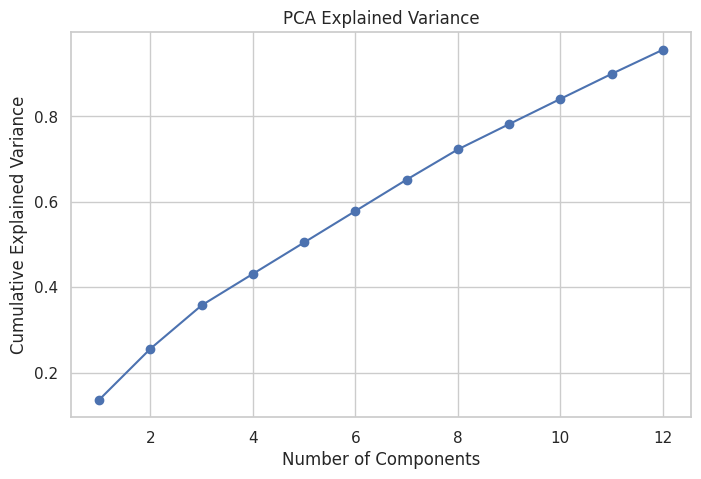

In [143]:
# قللنا العدد من 17 الى 12 وساعدنا هذا على تبسيط النموذج وتقليل التعقيد مع الاحتفظ باغلب المعلومات المهمة
plt.figure(figsize=(8,5))

plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),pca.explained_variance_ratio_.cumsum(),marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

In [154]:
lr_model = LogisticRegression(random_state=42, class_weight='balanced')
lr_model.fit(X_train_pca, y_train)
lr_pred = lr_model.predict(X_test_pca)

In [156]:
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train_pca, y_train)
rf_pred = rf_model.predict(X_test_pca)

In [157]:
lr_accuracy = accuracy_score(y_test, lr_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.62435
Random Forest Accuracy: 0.89945


In [158]:
# Precision
lr_precision = precision_score(y_test, lr_pred)
print("Logistic Regression Precision:", lr_precision)

rf_precision = precision_score(y_test, rf_pred)
print("Random Forest Precision:", rf_precision)

Logistic Regression Precision: 0.1630780523611451
Random Forest Precision: 0.42857142857142855


In [159]:
# Recall
lr_recall = recall_score(y_test, lr_pred)
print("Logistic Regression Recall:", lr_recall)

rf_recall = recall_score(y_test, rf_pred)
print("Random Forest Recall:", rf_recall)

Logistic Regression Recall: 0.6648379052369078
Random Forest Recall: 0.008977556109725686


In [149]:
# F1-score
lr_f1 = f1_score(y_test, lr_pred)
print("Logistic Regression F1-score:", lr_f1)

rf_f1 = f1_score(y_test, rf_pred)
print("Random Forest F1-score:", rf_f1)

Logistic Regression F1-score: 0.0
Random Forest F1-score: 0.026061776061776062


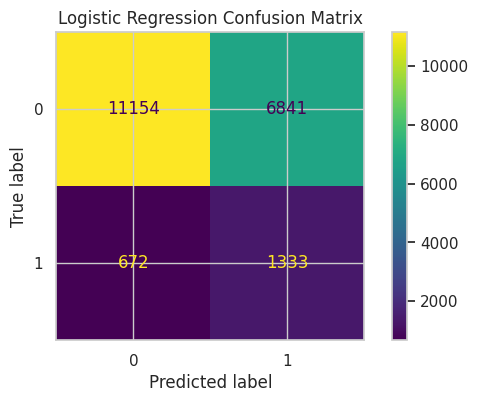

In [162]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

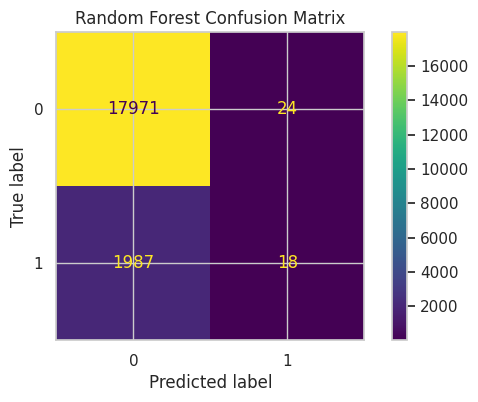

In [163]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()

## Conclusion

In this project, the Student Depression dataset was analyzed to predict whether a student is at risk of depression. The dataset was first explored using descriptive statistics and visualizations to better understand the data and identify important patterns.

The data was then cleaned by checking for missing values, duplicates, and outliers. Feature engineering was applied by creating new features (`study_balance` and `sleep_category`) to provide additional information for the models. Categorical variables were encoded, numerical features were scaled using StandardScaler, and PCA was applied to reduce the number of features from 17 to 12 while preserving 95% of the original variance.

Two machine learning models, Logistic Regression and Random Forest, were trained and evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix. During the evaluation, it was found that the dataset was imbalanced, so `class_weight='balanced'` was used to improve the models' ability to classify the minority class.

Overall, this project demonstrated the complete machine learning workflow, including data exploration, preprocessing, feature engineering, dimensionality reduction, model training, and performance evaluation.